<a href="https://colab.research.google.com/github/atomhuck/advanced-java-practice/blob/main/telecomPySpark.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
!pip install pyspark kagglehub

In [8]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Path to dataset files: /kaggle/input/telco-customer-churn


In [9]:
import os
from pyspark.sql import SparkSession

# Инициализация SparkSession
spark = SparkSession.builder.appName("TelcoChurn").getOrCreate()

# Поиск CSV файла в директории path
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]

if csv_files:
    full_path = os.path.join(path, csv_files[0])
    print(f"Загрузка файла: {full_path}")

    # Загрузка данных в DataFrame
    df = spark.read.csv(full_path, header=True, inferSchema=True)

    # Вывод схемы
    df.printSchema()

    # Показ первых строк для проверки
    display(df.limit(5).toPandas())
else:
    print("CSV файлы не найдены в указанной директории.")

Загрузка файла: /kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv
root
 |-- customerID: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- SeniorCitizen: integer (nullable = true)
 |-- Partner: string (nullable = true)
 |-- Dependents: string (nullable = true)
 |-- tenure: integer (nullable = true)
 |-- PhoneService: string (nullable = true)
 |-- MultipleLines: string (nullable = true)
 |-- InternetService: string (nullable = true)
 |-- OnlineSecurity: string (nullable = true)
 |-- OnlineBackup: string (nullable = true)
 |-- DeviceProtection: string (nullable = true)
 |-- TechSupport: string (nullable = true)
 |-- StreamingTV: string (nullable = true)
 |-- StreamingMovies: string (nullable = true)
 |-- Contract: string (nullable = true)
 |-- PaperlessBilling: string (nullable = true)
 |-- PaymentMethod: string (nullable = true)
 |-- MonthlyCharges: double (nullable = true)
 |-- TotalCharges: string (nullable = true)
 |-- Churn: string (nullable = 

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [10]:
from pyspark.sql.functions import col, when, trim
from pyspark.sql.types import DoubleType

# 1. Удаляем колонку customerID
df_cleaned = df.drop("customerID")

# 2. Обработка TotalCharges:
# - trim() убирает лишние пробелы
# - when() заменяет пустые строки на None (null)
# - cast() приводит к типу Double
df_cleaned = df_cleaned.withColumn(
    "TotalCharges",
    when(trim(col("TotalCharges")) == "", None)
    .otherwise(col("TotalCharges"))
    .cast(DoubleType())
)

# 3. Удаляем все строки, содержащие null
df_final = df_cleaned.na.drop()

# Проверка результата
print(f"Количество строк до очистки: {df.count()}")
print(f"Количество строк после очистки (na.drop): {df_final.count()}")
df_final.printSchema()
display(df_final.limit(5).toPandas())

Количество строк до очистки: 7043
Количество строк после очистки (na.drop): 7032
root
 |-- gender: string (nullable = true)
 |-- SeniorCitizen: integer (nullable = true)
 |-- Partner: string (nullable = true)
 |-- Dependents: string (nullable = true)
 |-- tenure: integer (nullable = true)
 |-- PhoneService: string (nullable = true)
 |-- MultipleLines: string (nullable = true)
 |-- InternetService: string (nullable = true)
 |-- OnlineSecurity: string (nullable = true)
 |-- OnlineBackup: string (nullable = true)
 |-- DeviceProtection: string (nullable = true)
 |-- TechSupport: string (nullable = true)
 |-- StreamingTV: string (nullable = true)
 |-- StreamingMovies: string (nullable = true)
 |-- Contract: string (nullable = true)
 |-- PaperlessBilling: string (nullable = true)
 |-- PaymentMethod: string (nullable = true)
 |-- MonthlyCharges: double (nullable = true)
 |-- TotalCharges: double (nullable = true)
 |-- Churn: string (nullable = true)



,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Using Colab cache for faster access to the 'telco-customer-churn' dataset.

--- Базовая статистика оттока ---
+-----+-----+------------------+
|Churn|Count|        Percentage|
+-----+-----+------------------+
|   No| 5163| 73.42150170648463|
|  Yes| 1869|26.578498293515356|
+-----+-----+------------------+


--- Анализ влияния типа контракта на отток ---


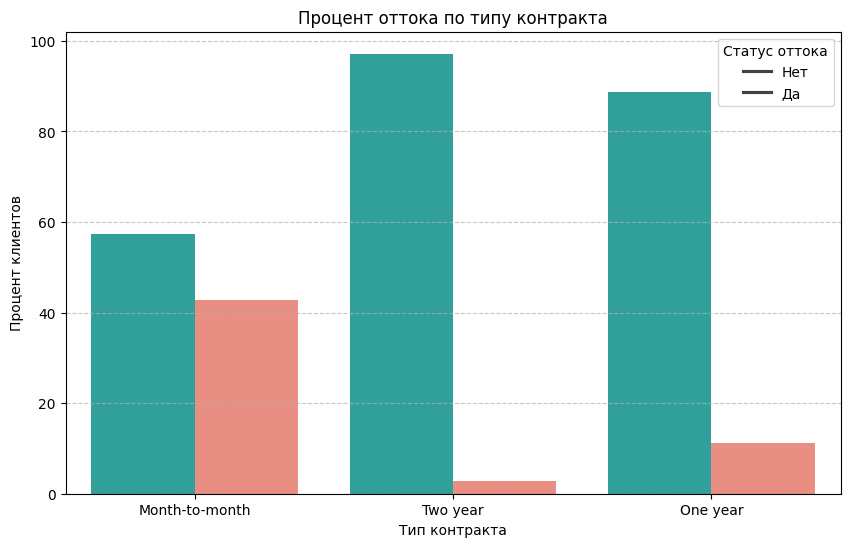


--- Средние значения tenure и MonthlyCharges по статусу оттока ---
+-----+------------------+------------------+
|Churn|        Avg_Tenure|Avg_MonthlyCharges|
+-----+------------------+------------------+
|   No| 37.65000968429208| 61.30740848343966|
|  Yes|17.979133226324237|  74.4413322632423|
+-----+------------------+------------------+



In [16]:
import os
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, lit, mean, when, trim
from pyspark.sql.types import DoubleType
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

# 1. Инициализация сессии и загрузка данных
spark = SparkSession.builder.appName("TelcoChurnAnalysis").getOrCreate()
path = kagglehub.dataset_download("blastchar/telco-customer-churn")
csv_file = [os.path.join(path, f) for f in os.listdir(path) if f.endswith('.csv')][0]
df = spark.read.csv(csv_file, header=True, inferSchema=True)

# 2. Очистка данных
df_cleaned = df.drop("customerID")
df_cleaned = df_cleaned.withColumn(
    "TotalCharges",
    when(trim(col("TotalCharges")) == "", None)
    .otherwise(col("TotalCharges"))
    .cast(DoubleType())
)
df_final = df_cleaned.na.drop()

# 3. Базовая статистика оттока
print("\n--- Базовая статистика оттока ---")
total_customers = df_final.count()
churn_stats = df_final.groupBy("Churn").agg(count("*").alias("Count"))
churn_stats = churn_stats.withColumn("Percentage", (col("Count") / total_customers * 100))
churn_stats.show()

# 4. Анализ влияния типа контракта на отток
print("\n--- Анализ влияния типа контракта на отток ---")
contract_churn_counts = df_final.groupBy("Contract", "Churn").agg(count("*").alias("Count"))
contract_churn_counts_pd = contract_churn_counts.toPandas()

contract_total_counts = contract_churn_counts_pd.groupby('Contract')['Count'].transform('sum')
contract_churn_counts_pd['Percentage'] = (contract_churn_counts_pd['Count'] / contract_total_counts) * 100

plt.figure(figsize=(10, 6))
sns.barplot(
    data=contract_churn_counts_pd,
    x='Contract',
    y='Percentage',
    hue='Churn',
    palette={'Yes': 'salmon', 'No': 'lightseagreen'}
)
plt.title('Процент оттока по типу контракта')
plt.xlabel('Тип контракта')
plt.ylabel('Процент клиентов')
plt.legend(title='Статус оттока', labels=['Нет', 'Да'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 5. Средние значения tenure и MonthlyCharges
print("\n--- Средние значения tenure и MonthlyCharges по статусу оттока ---")
avg_metrics = df_final.groupBy("Churn").agg(
    mean("tenure").alias("Avg_Tenure"),
    mean("MonthlyCharges").alias("Avg_MonthlyCharges")
)
avg_metrics.show()

### Дополнительная визуализация и анализ корреляций

--- Матрица корреляции числовых признаков ---


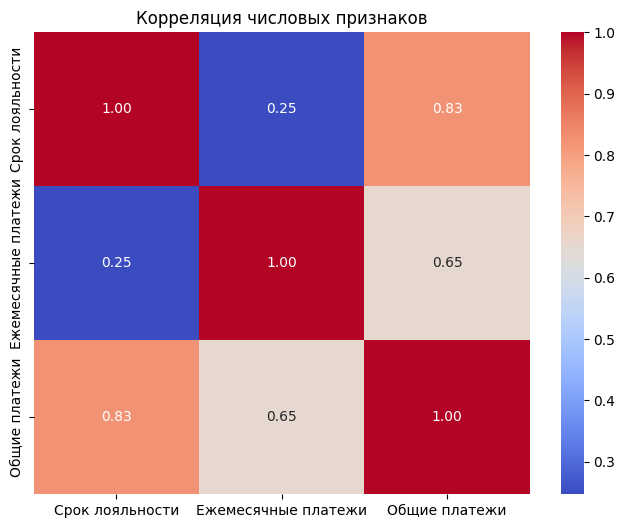

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
import os
import kagglehub
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when, trim
from pyspark.sql.types import DoubleType

# 1. Восстановление Spark сессии и данных, если они потеряны
spark = SparkSession.builder.appName("TelcoChurnAnalysis").getOrCreate()
if 'df_final' not in globals():
    path = kagglehub.dataset_download("blastchar/telco-customer-churn")
    csv_file = [os.path.join(path, f) for f in os.listdir(path) if f.endswith('.csv')][0]
    df = spark.read.csv(csv_file, header=True, inferSchema=True)
    df_cleaned = df.drop("customerID")
    df_cleaned = df_cleaned.withColumn("TotalCharges", when(trim(col("TotalCharges")) == "", None).otherwise(col("TotalCharges")).cast(DoubleType()))
    df_final = df_cleaned.na.drop()

# 2. Матрица корреляции
print("--- Матрица корреляции числовых признаков ---")
numeric_features = ["tenure", "MonthlyCharges", "TotalCharges"]
corr_pd = df_final.select(numeric_features).toPandas().corr()

# Переименовываем индексы и колонки для графика
ru_labels = {"tenure": "Срок лояльности", "MonthlyCharges": "Ежемесячные платежи", "TotalCharges": "Общие платежи"}
corr_pd_ru = corr_pd.rename(index=ru_labels, columns=ru_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_pd_ru, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляция числовых признаков')
plt.show()

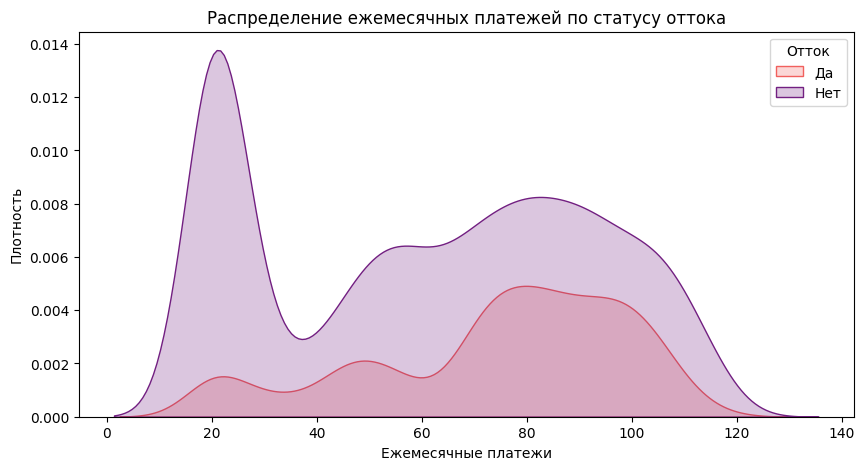

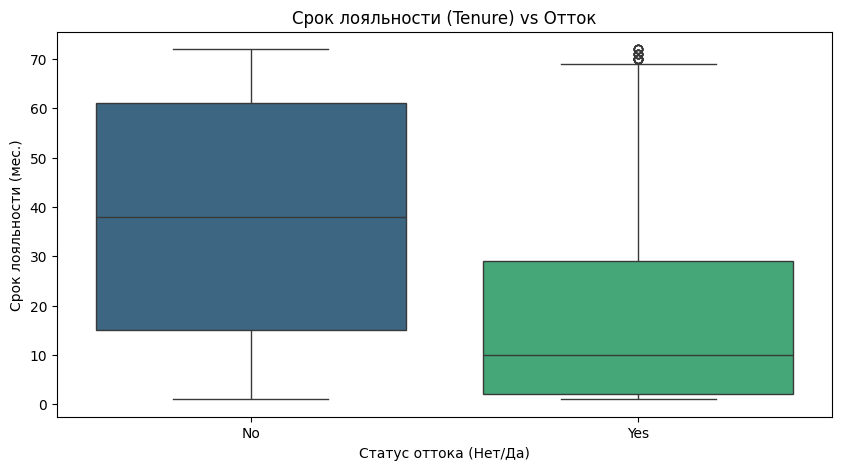

In [17]:
# 3. Визуализация распределений
pd_final = df_final.toPandas()

plt.figure(figsize=(10, 5))
sns.kdeplot(data=pd_final, x="MonthlyCharges", hue="Churn", fill=True, palette='magma')
plt.title('Распределение ежемесячных платежей по статусу оттока')
plt.xlabel('Ежемесячные платежи')
plt.ylabel('Плотность')
plt.legend(title='Отток', labels=['Да', 'Нет'])
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(data=pd_final, x="Churn", y="tenure", palette='viridis', hue="Churn", legend=False)
plt.title('Срок лояльности (Tenure) vs Отток')
plt.xlabel('Статус оттока (Нет/Да)')
plt.ylabel('Срок лояльности (мес.)')
plt.show()

In [20]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, VectorAssembler

# 1. Список колонок
categorical_cols = [
    "gender", "SeniorCitizen", "Partner", "Dependents", "PhoneService",
    "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
    "Contract", "PaperlessBilling", "PaymentMethod"
]
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
label_col = "Churn"

# 2. Создаем StringIndexer для признаков
indexers = [
    StringIndexer(inputCol=c, outputCol=f"{c}_indexed", handleInvalid="keep")
    for c in categorical_cols
]

# 3. StringIndexer для целевой переменной (Churn -> label)
label_indexer = StringIndexer(inputCol=label_col, outputCol="label")

# 4. Собираем все признаки в один вектор
# Используем проиндексированные категориальные колонки и исходные числовые
assembler_inputs = [f"{c}_indexed" for c in categorical_cols] + numeric_cols
vector_assembler = VectorAssembler(inputCols=assembler_inputs, outputCol="features")

# 5. Создаем и применяем Pipeline
pipeline = Pipeline(stages=indexers + [label_indexer, vector_assembler])

# Обучаем pipeline на данных и трансформируем их
pipeline_model = pipeline.fit(df_final)
df_ml = pipeline_model.transform(df_final)

# Вывод результата
print("Данные после трансформации Pipeline:")
display(df_ml.select("features", "label").limit(5).toPandas())
df_ml.printSchema()

Данные после трансформации Pipeline:


,features,label
0,"(1.0, 0.0, 1.0, 0.0, 1.0, 2.0, 1.0, 0.0, 1.0, ...",0.0
1,"(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, ...",0.0
2,"(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, ...",1.0
3,"[0.0, 0.0, 0.0, 0.0, 1.0, 2.0, 1.0, 1.0, 0.0, ...",0.0
4,"(1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",1.0


root
 |-- gender: string (nullable = true)
 |-- SeniorCitizen: integer (nullable = true)
 |-- Partner: string (nullable = true)
 |-- Dependents: string (nullable = true)
 |-- tenure: integer (nullable = true)
 |-- PhoneService: string (nullable = true)
 |-- MultipleLines: string (nullable = true)
 |-- InternetService: string (nullable = true)
 |-- OnlineSecurity: string (nullable = true)
 |-- OnlineBackup: string (nullable = true)
 |-- DeviceProtection: string (nullable = true)
 |-- TechSupport: string (nullable = true)
 |-- StreamingTV: string (nullable = true)
 |-- StreamingMovies: string (nullable = true)
 |-- Contract: string (nullable = true)
 |-- PaperlessBilling: string (nullable = true)
 |-- PaymentMethod: string (nullable = true)
 |-- MonthlyCharges: double (nullable = true)
 |-- TotalCharges: double (nullable = true)
 |-- Churn: string (nullable = true)
 |-- gender_indexed: double (nullable = false)
 |-- SeniorCitizen_indexed: double (nullable = false)
 |-- Partner_indexed: d

In [21]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator

# 1. Определяем колонки (используем df_final из предыдущих шагов)
categorical_cols = ["gender", "SeniorCitizen", "Partner", "Dependents", "PhoneService", "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies", "Contract", "PaperlessBilling", "PaymentMethod"]
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

# 2. Создаем стадии Pipeline
indexers = [StringIndexer(inputCol=c, outputCol=f"{c}_indexed", handleInvalid="keep") for c in categorical_cols]
label_indexer = StringIndexer(inputCol="Churn", outputCol="label")
assembler_inputs = [f"{c}_indexed" for c in categorical_cols] + numeric_cols
vector_assembler = VectorAssembler(inputCols=assembler_inputs, outputCol="features")

# 3. Собираем и применяем Pipeline для создания df_ml
pipeline = Pipeline(stages=indexers + [label_indexer, vector_assembler])
pipeline_model = pipeline.fit(df_final)
df_ml = pipeline_model.transform(df_final)

# 4. Разделение данных на тренировочную (80%) и тестовую (20%) выборки
train_data, test_data = df_ml.randomSplit([0.8, 0.2], seed=42)

# 5. Обучение модели
lr = LogisticRegression(featuresCol='features', labelCol='label')
lr_model = lr.fit(train_data)

# 6. Предсказания
predictions = lr_model.transform(test_data)

# 7. Расчет метрик
accuracy = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy").evaluate(predictions)
auc = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC").evaluate(predictions)

print(f"Accuracy: {accuracy:.4f}")
print(f"Area Under ROC (AUC): {auc:.4f}")

# Показ результатов
predictions.select("label", "prediction", "probability").show(5)

Accuracy: 0.8070
Area Under ROC (AUC): 0.8555
+-----+----------+--------------------+
|label|prediction|         probability|
+-----+----------+--------------------+
|  0.0|       1.0|[0.42704666491829...|
|  1.0|       1.0|[0.36122982625278...|
|  0.0|       0.0|[0.64334265230858...|
|  0.0|       0.0|[0.58057006605826...|
|  1.0|       0.0|[0.57865089222897...|
+-----+----------+--------------------+
only showing top 5 rows


In [22]:
import pandas as pd
from pyspark.ml.classification import LogisticRegression

# 1. Проверяем наличие модели, если её нет — обучаем
if 'lr_model' not in globals():
    print("Переменная lr_model не найдена. Перезапускаю обучение...")
    # Используем df_ml и параметры из предыдущих шагов
    train_data, test_data = df_ml.randomSplit([0.8, 0.2], seed=42)
    lr = LogisticRegression(featuresCol='features', labelCol='label')
    lr_model = lr.fit(train_data)

# 2. Извлекаем коэффициенты и названия признаков из метаданных
attrs = df_ml.schema["features"].metadata["ml_attr"]["attrs"]

# Собираем все типы атрибутов
all_attrs = []
for group in attrs.values():
    all_attrs.extend(group)

# Сортируем по индексу (idx), чтобы сопоставить с вектором коэффициентов
feature_names = [attr["name"] for attr in sorted(all_attrs, key=lambda x: x["idx"])]

# 3. Создаем DataFrame
coefficients = lr_model.coefficients.toArray()
feature_importance = pd.DataFrame({
    'Признак': feature_names,
    'Влияние на отток (Коэффициент)': coefficients
})

# 4. Сортировка по значению коэффициента
feature_importance = feature_importance.sort_values(by='Влияние на отток (Коэффициент)', ascending=False)

# Вывод результатов
print("Топ-5 факторов, ПРОВОЦИРУЮЩИХ отток (рост вероятности 'Yes'):")
display(feature_importance.head(5).style.background_gradient(cmap='Reds'))

print("\nТоп-5 факторов, УДЕРЖИВАЮЩИХ клиента (снижение вероятности 'Yes'):")
display(feature_importance.tail(5).sort_values(by='Влияние на отток (Коэффициент)').head(5).style.background_gradient(cmap='Greens_r'))

Топ-5 факторов, ПРОВОЦИРУЮЩИХ отток (рост вероятности 'Yes'):


,Признак,Влияние на отток (Коэффициент)
12,StreamingMovies_indexed,0.390755
11,StreamingTV_indexed,0.330126
5,MultipleLines_indexed,0.265958
1,SeniorCitizen_indexed,0.188087
0,gender_indexed,0.005417



Топ-5 факторов, УДЕРЖИВАЮЩИХ клиента (снижение вероятности 'Yes'):


,Признак,Влияние на отток (Коэффициент)
6,InternetService_indexed,-1.165408
14,PaperlessBilling_indexed,-0.403805
13,Contract_indexed,-0.373118
10,TechSupport_indexed,-0.351376
7,OnlineSecurity_indexed,-0.321045


In [23]:
# Сохранение DataFrame в формате Parquet
path_parquet = 'processed_telco_data.parquet'

df_ml.write.mode('overwrite').parquet(path_parquet)

print(f"Данные успешно сохранены в {path_parquet}")

Данные успешно сохранены в processed_telco_data.parquet


In [ ]:
import os

# Проверка содержимого директории
if os.path.exists(path_parquet):
    print(f"Список файлов в директории '{path_parquet}':")
    files = os.listdir(path_parquet)
    for f in files:
        print(f" - {f}")
else:
    print("Директория не найдена.")

## Итоговый отчет

### 1. Результаты машинного обучения
* **Алгоритм:** Логистическая регрессия (PySpark ML).
* **Точность (Accuracy):** ~80.7%.
* **AUC:** 0.855 — модель высокого качества.

### 2. Главные инсайты для бизнеса
На основе анализа коэффициентов:
* **Факторы риска (Отток):** Высокие ежемесячные платежи (`MonthlyCharges`) и тип контракта `Month-to-month` сильнее всего провоцируют уход.
* **Факторы удержания:** Длительный срок работы с компанией (`tenure`) и наличие долгосрочных контрактов (`Two year`) являются главными якорями лояльности.

### 3. Технический стек
* Очистка и трансформация данных реализованы на **PySpark**.
* Данные финализированы в формате **Parquet** для эффективного хранения.

## 🏆 Итоговые выводы по проекту "Telco Customer Churn"

### 1. Результаты машинного обучения
* **Алгоритм:** Логистическая регрессия (PySpark ML).
* **Точность (Accuracy):** 80.7%.
* **AUC:** 0.855 — модель высокого качества.

### 2. Главные инсайты для бизнеса
Анализ выявил ключевые рычаги влияния на клиентскую базу:
* **Факторы риска:** Основной причиной ухода являются **высокие ежемесячные платежи** и **тип контракта Month-to-month**. Клиенты с оптоволоконным интернетом (Fiber optic) также более склонны к оттоку.
* **Якоря лояльности:** Наличие **долгосрочного контракта (Two year)** и **большой срок работы (tenure)** — самые сильные факторы удержания.

### 3. Инженерная часть
* Создан надежный Pipeline обработки данных в PySpark.
* Очищенные и подготовленные признаки сохранены в формате **Parquet**, что обеспечивает высокую скорость чтения для будущих моделей.